$$\frac{\partial A}{\partial z} = -\frac{\alpha}{2} A - \frac{i}{2} \beta_2 \frac{\partial^2 A}{\partial^2 T} + i \gamma |A|^2 A$$

$$\begin{align}
\hat N &= i \gamma |A|^2 \\
\hat D &= -\frac{\alpha}{2} - \frac{i}{2} \beta_2 \frac{\partial^2}{\partial^2 T} \\
\hat D(\omega) &= -\frac{\alpha}{2} + \frac{i}{2} \beta_2 \omega^2 \\
\end{align}$$

$$T = t-\frac{z}{v_g}$$

In [1]:
import numpy as np

def D_freq(f: np.ndarray, beta2, **kwargs) -> np.ndarray:
    '''
    f: Frequency corresponding to A (cycles/sec)
    '''
    omega = 2 * np.pi * f
    return 1j * beta2 / 2 * omega ** 2

def apply_D(A, h, dt, **kwargs) -> np.ndarray:
    '''
    A: field amplitude (in the time domain)
    h: step length in z
    dt: distance between points in t
    '''
    A0_f = np.fft.fft(A)
    f = np.fft.fftfreq(A.size, d=dt)
    D = D_freq(f, **kwargs)

    A1_f = np.exp( h * D / 2 ) * A0_f
    return np.fft.ifft(A1_f)

def N_t(A: np.ndarray, gamma, **kwargs) -> np.ndarray:
    '''
    A: field amplitude (in the time domain)
    '''
    N = 1j * gamma * np.abs(A) ** 2
    return N

# Simulation Loop

So we find `N(z+h)` by running through the calculation assuming `N(z+h) = N(z)` to find `A(z+h)` to plug back in to find `N(z+h)`

THIS CODE DOES NOT DO:
$$e^{\frac{h}{2}D}[ e^{\frac{h}{2}N}e^{\frac{h}{2}D}A(z, T) e^{\frac{h}{2}N}e^{\frac{h}{2}D}A(z + h, T) ]$$

It does
$$e^{\frac{h}{2}D} e^{\frac{h}{2} ( N(A(z)) + N(A(z+h)) )} e^{\frac{h}{2}D} A(z)$$

```python
N_z = N(A(z))
N_zh = N(A(z+h))
DA_z = exp(D * h / 2) A(z, T)
A_mid = exp(( N(A(z)) + N(A(z+h)) ) * h / 2) exp(D * h / 2) A(z, T)
```

In [5]:
from tqdm import tqdm

def split_step(A_0, t, Z, n_integral_iterations = 10, **kwargs):
    dZ = Z[1] - Z[0]
    
    A = np.zeros((Z.size, A_0.size), dtype=complex)
    A[0] = A_0
    
    for ind, A_z in enumerate(A[:-1]):
        A_zh = np.copy(A_z)
        N_z = N_t(A_z, **kwargs)
        DA_z = apply_D(A_z, dZ, t[1] - t[0], **kwargs)

        for _ in range(n_integral_iterations):
            N_zh = N_t(A_zh, **kwargs)

            A_mid = np.exp( dZ * ( N_z + N_zh ) / 2 ) * DA_z
            A_zh = apply_D(A_mid, dZ, t[1] - t[0], **kwargs)
        A[ind + 1] = A_zh
    return A

# Getting constants figured out

In [6]:
beta2 = -4.20056799728266e-27 # s^2 m^-1

A_eff = 50e-12 # in m^2
n_2 = 3.2e-20 # m^2 W^-1
lambda_0 = 1.55e-6
gamma = 2 * np.pi * n_2 / (lambda_0 * A_eff)

N = 1
T_0 = 1e-12
FWHM = 1.76 * T_0
L_D = T_0 ** 2 / np.abs( beta2 )
P_0 = N ** 2 / ( L_D * gamma )
print(f'This simulation is happening for\n\tFWHM: {FWHM}s\n\tPower: {P_0} W\n\tN: {N}\n\tL_D: {L_D} m')

L_NL = 1 / ( gamma * P_0 )
assert np.isclose(L_D / L_NL, N ** 2), 'N is not self consistent!'

This simulation is happening for
	FWHM: 1.76e-12s
	Power: 1.6191231232340562 W
	N: 1
	L_D: 238.0630430567719 m


# 1D Case (linearly polarized)

In [7]:
params = {
    'beta2': beta2,
    'gamma': gamma
}

t = np.linspace(-80e-12, 80e-12, 2048)
Z = np.linspace(0, 10*np.pi/2 * L_D, 2048)

A_0 = np.sqrt(P_0) / np.cosh(t / T_0)
print(f'This travels to:\n\tZ: {Z[-1]:.2f} m\n\tXi: {Z[-1] / L_D}')

A_out = split_step(A_0, t, Z, **params)

This travels to:
	Z: 3739.49 m
	Xi: 15.707963267948966


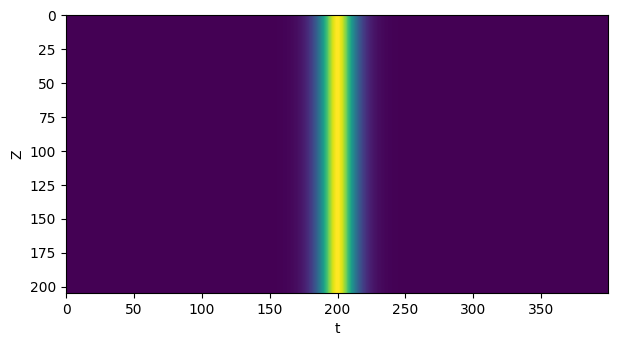

In [8]:
import matplotlib.pyplot as plt

mid = A_out[0].size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(A_out[::10,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

(-5e-12, 5e-12)

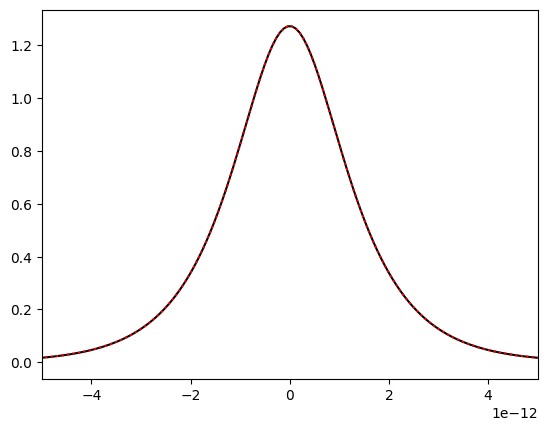

In [9]:
plt.plot(t, np.abs(A_0), 'k')
plt.plot(t, np.abs(A_out[0]), 'r:')
plt.xlim(-5e-12,5e-12)

# 2D case

In [50]:
theta = np.pi / 3

params = {
    'beta2': beta2,
    'gamma': gamma
}

t = np.linspace(-80e-12, 80e-12, 2048)
Z = np.linspace(0, 10 * np.pi/2 * L_D, 2048)
# Z = np.linspace(0, 0.4, 10)
print(f'This travels to:\n\tZ: {Z[-1]:.2f} m\n\tXi: {Z[-1] / L_D}')

A0_X = np.cos(theta) * np.sqrt(P_0) / np.cosh(t / T_0)
A0_Y = np.sin(theta) * np.sqrt(P_0) / np.cosh(t / T_0)

A_X = split_step(A0_X, t, Z, **params)
A_Y = split_step(A0_Y, t, Z, **params)

This travels to:
	Z: 3739.49 m
	Xi: 15.707963267948966


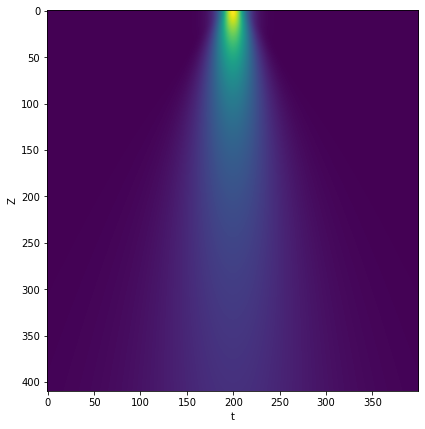

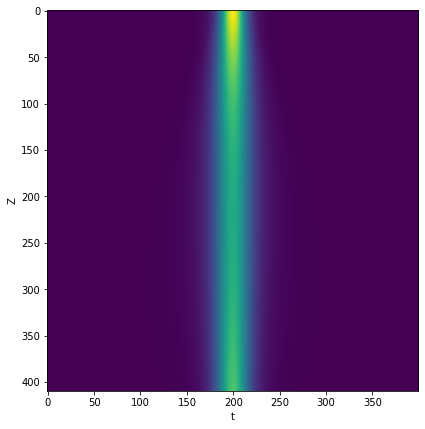

In [51]:
import matplotlib.pyplot as plt

mid = A_X[0].size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(A_X[::5,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

mid = A_Y[0].size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(A_Y[::5,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

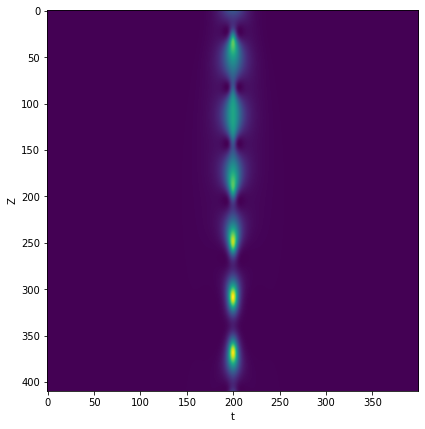

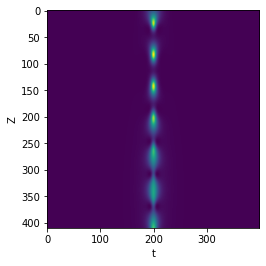

In [9]:
# LCP = ( np.abs(A_X) ** 2 + np.abs(1j * A_Y) ** 2 ) / 2
LCP = ( A_X + 1j * A_Y ) / np.sqrt( 2 )
RCP = ( A_X - 1j * A_Y ) / np.sqrt( 2 )

mid = LCP[0].size // 2
plt.figure(figsize=(7,7))
plt.imshow(np.abs(LCP[::5,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

plt.imshow(np.abs(RCP[::5,mid-200:mid+200])**2)
plt.ylabel('Z')
plt.xlabel('t')
plt.show()

# Polarization Study

(-1.0, 1.0)

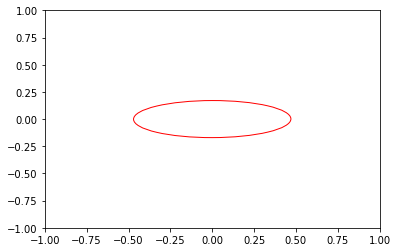

In [10]:
from matplotlib import patches
mid = A_X[0].size // 2

def find_ellipse(vec):
    x_amp, y_amp = vec
    
    polarization = np.array([x_amp, y_amp])
    polarization /= np.sqrt( np.sum( np.abs(polarization) ** 2 ) )
    theta = np.arccos( np.abs(polarization[0]) )
    alpha = np.angle(polarization)
    
    delta = alpha[1] - alpha[0]
    phi = np.arctan(np.tan(2 * theta) * np.cos(delta)) / 2
    return theta, delta, phi

def plot_ellipse(theta, delta, phi, mag=1, **kwargs):
    A = mag * np.sqrt(( 1 + np.sqrt(1 - np.sin(2 * theta) ** 2 * np.sin(delta) ** 2) ) / 2)
    B = mag * np.sqrt(( 1 - np.sqrt(1 - np.sin(2 * theta) ** 2 * np.sin(delta) ** 2) ) / 2)
    
    phi_deg = phi * 180 / np.pi
    el = patches.Ellipse((0,0), A, B, angle=phi_deg, **kwargs)
    return el

for x_amp, y_amp in zip(A_X[:,mid], A_Y[:,mid]):
    polarization = np.array([x_amp, y_amp])
    polarization /= np.sqrt( np.sum( np.abs(polarization) ** 2 ) )
    theta = np.arccos( np.abs(polarization[0]) )
    alpha = np.angle(polarization)
    
    delta = alpha[1] - alpha[0]
#     RCP = ( np.cos(theta) + 1j * np.sin(theta) * np.exp(1j * delta) ) \
#                 * np.exp(1j * alpha[0]) / np.sqrt(2)
#     LCP = ( np.cos(theta) + 1j * np.sin(theta) * np.exp(1j * delta) ) \
#                 * np.exp(1j * alpha[0]) / np.sqrt(2)
    
#     print(RCP, LCP)
    A = np.sqrt(( 1 + np.sqrt(1 - np.sin(2 * theta) ** 2 * np.sin(delta) ** 2) ) / 2)
    B = np.sqrt(( 1 - np.sqrt(1 - np.sin(2 * theta) ** 2 * np.sin(delta) ** 2) ) / 2)
    phi = np.arctan(np.tan(2 * theta) * np.cos(delta)) / 2

el = patches.Ellipse((0,0), A, B, phi, fill=False, color='red')
fig, ax = plt.subplots(1,1)
ax.add_patch(el)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

This travels to:
	Z: 186.97 m
	Xi: 0.7853981633974483


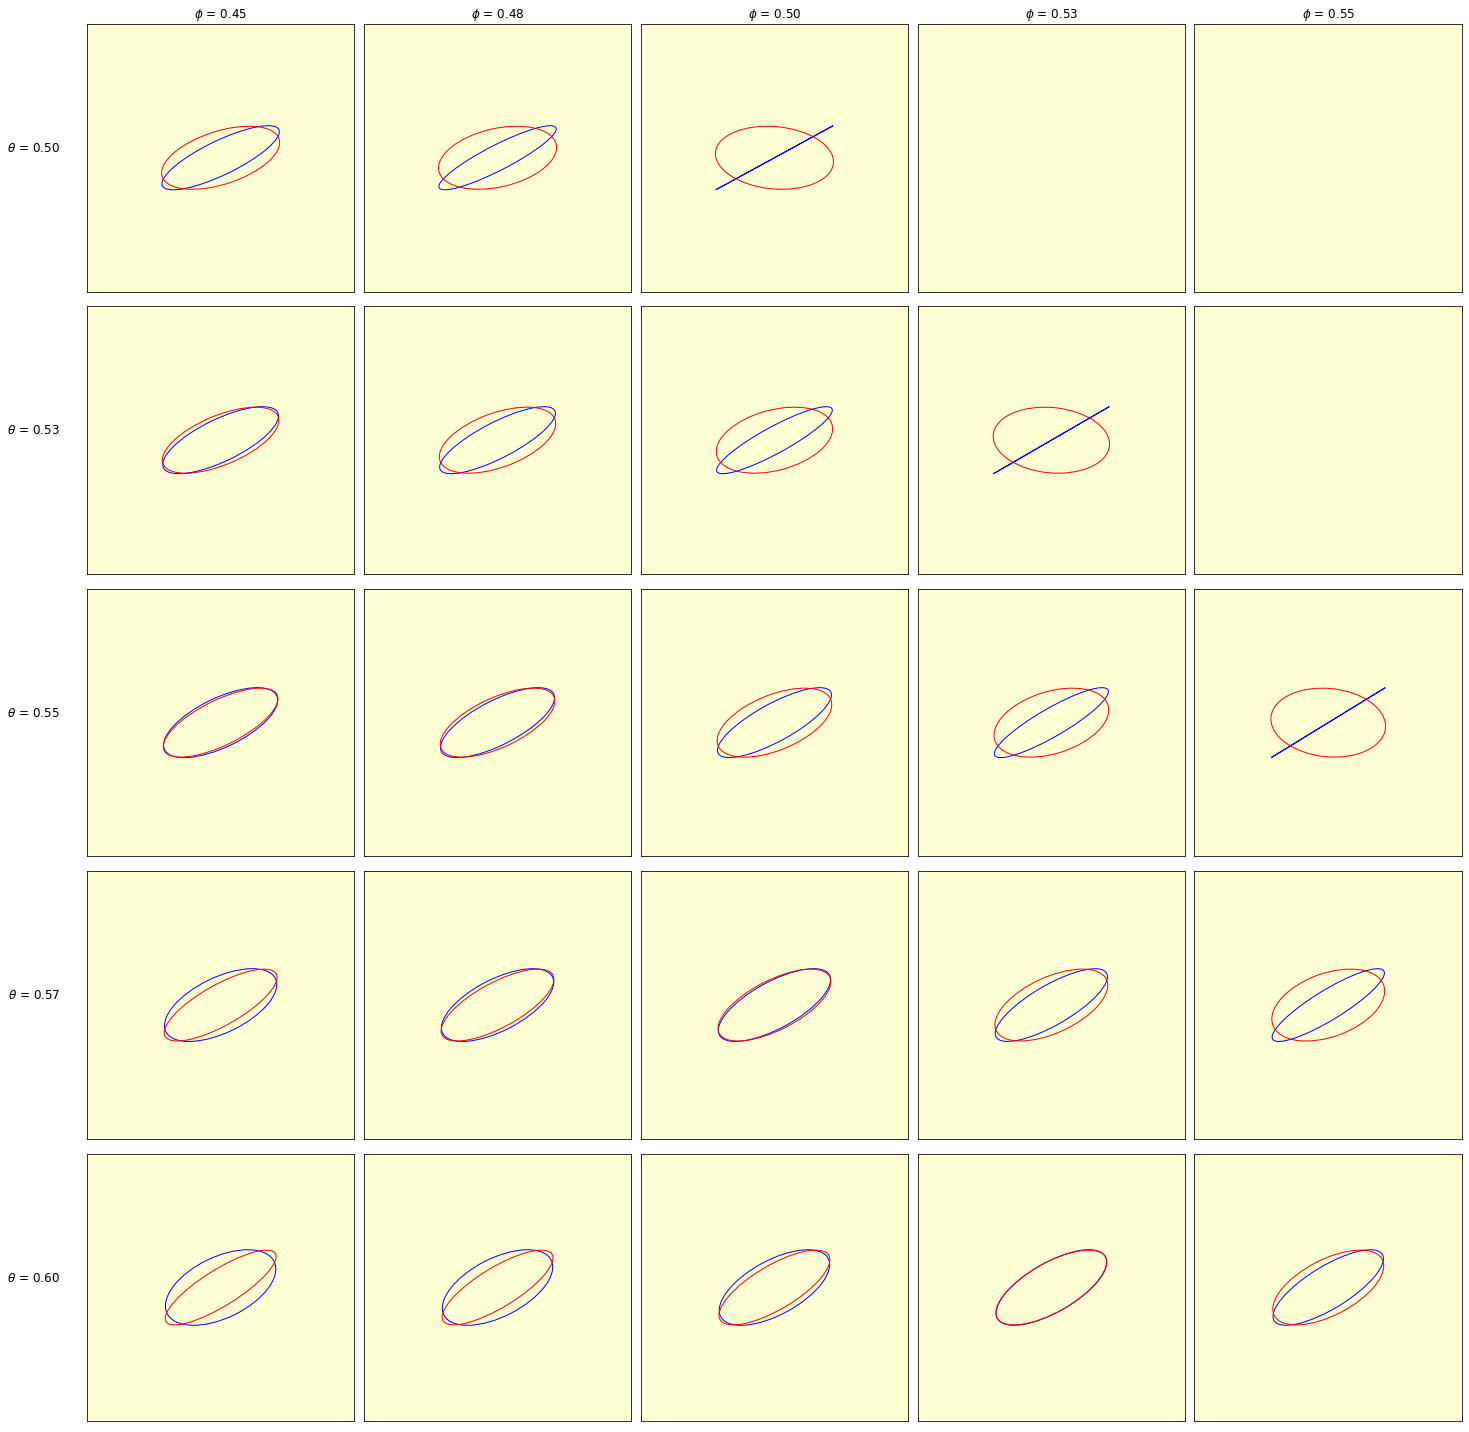

In [11]:
params = {
    'beta2': beta2,
    'gamma': gamma
}

t = np.linspace(-80e-12, 80e-12, 1000)
Z = np.linspace(0, L_D * np.pi / 4, 10)
# Z = np.linspace(0, 0.4, 10)
print(f'This travels to:\n\tZ: {Z[-1]:.2f} m\n\tXi: {Z[-1] / L_D}')

# P_0 = 6.476492492936225
P_0 = 0.6
A0 = np.sqrt(P_0) / np.cosh(t / T_0)

HWP = np.pi / 4

thetas = np.linspace(0.5, 0.6, 5)
phis = np.linspace(0.45, 0.55, 5)

fig, axes = plt.subplots(len(thetas), len(phis), figsize=(20,20))

for ind_t, theta in enumerate(thetas):
    for ind_p, phi in enumerate(phis):   
        if ind_t == 0:
            axes[ind_t, ind_p].set_title(f'$\phi$ = {phi:.2f}')
        if ind_p == 0:
            axes[ind_t, ind_p].set_title(f'$\\theta$ = {theta:.2f}', y=0.5, x=-0.1, loc='right')
        
        if phi == theta and phi == 0:
            beta = np.arccos( 0 )
        elif np.abs( np.tan( 2 * phi ) / np.tan( 2 * theta ) ) > 1:
#             print(theta, phi)
            continue
        else:
            beta = np.arccos( np.tan( 2 * phi ) / np.tan( 2 * theta ) )

        A0_X = np.cos(theta) * A0
        A0_Y = np.sin(theta) * np.exp(1j * beta) * A0

        A_X = split_step(A0_X, t, Z, **params)
        A_Y = split_step(A0_Y, t, Z, **params)
        
        mid = A_X[0].size // 2
        
        x_amp = A_X[-1,mid]
        y_amp = A_Y[-1,mid]
        
        '''
        Adding quarter and half-wave plates
        '''
        y_amp *= 1j
        
        f_amp = np.cos(HWP) * x_amp - np.sin(HWP) * y_amp
        s_amp = np.sin(HWP) * x_amp + np.cos(HWP) * y_amp
        
        s_amp *= -1
        
        x_amp = np.cos(-HWP) * f_amp - np.sin(-HWP) * s_amp
        y_amp = np.sin(-HWP) * f_amp + np.cos(-HWP) * s_amp

        el = plot_ellipse(theta, beta, phi, color='blue', fill=False)
        axes[ind_t, ind_p].add_patch(el)
        
        theta_f, beta_f, phi_f = find_ellipse( (x_amp, y_amp) )
        mag = np.sqrt( np.abs(A_X[-1,mid]) ** 2 + np.abs(A_Y[-1,mid]) ** 2 ) / np.sqrt( P_0 )
        el_f = plot_ellipse(theta_f, beta_f, phi_f, color='red', fill=False)
        axes[ind_t, ind_p].add_patch(el_f)

for ax in axes.flatten():
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    ax.set_facecolor('xkcd:eggshell')

plt.tight_layout()
plt.show()

## Polarization Animation

In [72]:
params = {
    'beta2': beta2,
    'gamma': gamma
}

t = np.linspace(-80e-12, 80e-12, 2048)
Z = np.linspace(0, 10*np.pi/2 * L_D, 2048)
# Z = np.linspace(0, 6, 100)

# P_0 = 3.6430270272766263
# P_0 = 6.476492492936225
A0 = np.sqrt(P_0) / np.cosh(t / T_0)
print(f'This travels to:\n\tZ: {Z[-1]:.2f} m\n\tXi: {Z[-1] / L_D}\n\tP_O: {P_0} W')

theta = np.pi / 4
phi = 0.5
beta = np.arccos( np.tan( 2 * phi ) / np.tan( 2 * theta ) )

# theta = np.pi / 2
# phi = np.pi / 2
# beta = np.arccos( np.tan( 2 * phi ) / np.tan( 2 * theta ) )

# A0_X = np.cos(theta) * A0
# A0_Y = np.sin(theta) * np.exp(1j * beta) * A0

A0_X = A0
A0_Y = A0

A_X = split_step(A0_X, t, Z, **params)
A_Y = split_step(A0_Y, t, Z, **params)

This travels to:
	Z: 3739.49 m
	Xi: 15.707963267948966
	P_O: 1.6191231232340562 W


In [73]:
from matplotlib import animation
from copy import copy

fig, ax = plt.subplots(1, 2, figsize=(10,5))

start_ind = min(np.argwhere(t > (-10 * T_0)).flatten())
end_ind = min(np.argwhere(t > (10 * T_0)).flatten())

A0_mag = np.sqrt( np.abs(A0_X) ** 2 + np.abs(A0_Y) ** 2 )
Af_mag = np.sqrt( np.abs(A_X[-1,:]) ** 2 + np.abs(A_Y[-1,:]) ** 2 )

ax[0].plot(t[start_ind:end_ind], A0_mag[start_ind:end_ind], label='input')
ax[0].plot(t[start_ind:end_ind], Af_mag[start_ind:end_ind], 'r', label='output')

ax[0].legend()

ax[1].set_xlim(-1,1)
ax[1].set_ylim(-1,1)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_aspect('equal')

def animate(ind):
    ax[1].patches.clear()
    
    x_amp = A_X[-1, ind]
    y_amp = A_Y[-1, ind]
    
    mag = np.sqrt(np.abs(A_X[-1, ind]) ** 2 + np.abs(A_Y[-1, ind]) ** 2)
    theta_f, beta_f, phi_f = find_ellipse( (x_amp, y_amp) )
    ellipse = plot_ellipse(theta_f, beta_f, phi_f, color='red', mag=1.5, fill=False)
    
    patch = ax[1].add_patch( ellipse)

    if len(ax[0].lines) > 2:
        ax[0].lines[-1].remove()
        
    ax[0].axvline(t[ind], color='g', lw=0.5)
    return [ patch ]
    
ani = animation.FuncAnimation(fig, animate, frames=range(start_ind, end_ind + 1, 20), interval=1000/24)

plt.close()

from IPython.display import HTML
HTML(ani.to_jshtml())

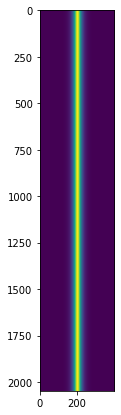

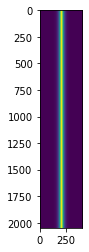

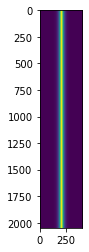

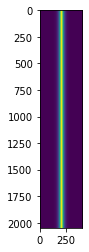

In [74]:
# mag = np.sqrt( np.abs(A_X) ** 2 + np.abs(A_Y) ** 2 )
LCP = ( A_X + 1j * A_Y ) / np.sqrt( 2 )
RCP = ( A_X - 1j * A_Y ) / np.sqrt( 2 )

mid = LCP[0].size // 2

plt.figure(figsize=(7,7))
plt.imshow(np.abs(A_X[:,mid-200:mid+200]))
plt.show()
plt.imshow(np.abs(A_Y[:,mid-200:mid+200]))
plt.show()

plt.imshow(np.abs(LCP[:,mid-200:mid+200]))
plt.show()
plt.imshow(np.abs(RCP[:,mid-200:mid+200]))
plt.show()